# Track A — Apply the Reading Framework
Run each block, look at the plot, and answer in the **answer** cell. Bring your answers back to the group.

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.titleweight": "bold"})
BLUE, ORANGE, GREEN = "#1f6feb", "#fb8500", "#2a9d8f"

# Corrected DATA path: files are directly in the current working directory, not in a 'data' subfolder.
DATA = Path.cwd()
energy = pd.read_csv(DATA / "energy_dataset.csv"); energy["time"] = pd.to_datetime(energy["time"], utc=True)
weather = pd.read_csv(DATA / "weather_features.csv"); weather["dt_iso"] = pd.to_datetime(weather["dt_iso"], utc=True)
weather["city_name"] = weather["city_name"].str.strip()
load = energy.set_index("time")["total load actual"]

## 1 · Frequency
Run the cell. **Q:** what is the time step? which lags will be meaningful?

In [ ]:
energy["time"].diff().value_counts().head()

,count
time,
0 days 01:00:00,35063


> **Answer:** The dataset has an hourly time step. Meaningful lags include 24 hours for the same hour yesterday, 48 hours for two days ago, and 168 hours for the same hour one week ago.


## 2 · Trend & yearly cycle
Run the cells. **Q:** any level changes or abnormal periods? seasonal variation across the year?

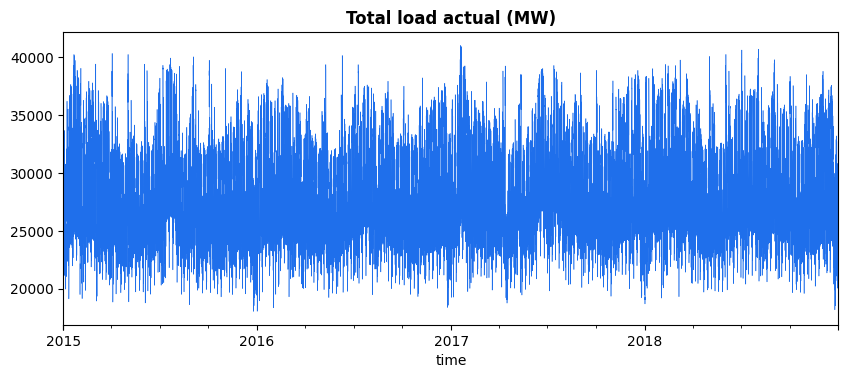

In [ ]:
load.plot(lw=0.4, color=BLUE, title="Total load actual (MW)"); plt.show()

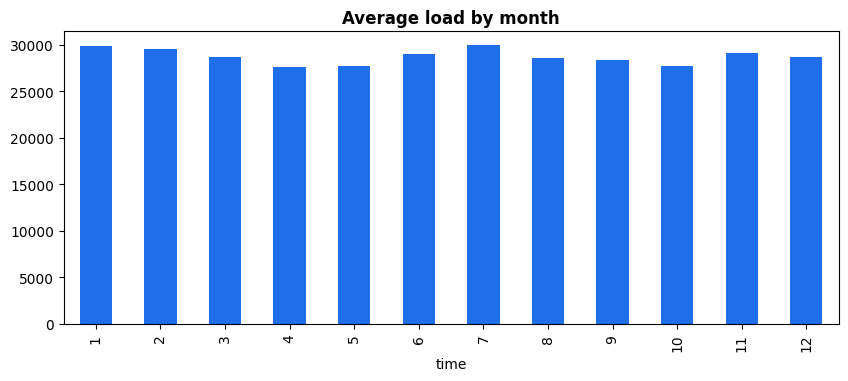

In [ ]:
load.groupby(load.index.month).mean().plot.bar(color=BLUE, title="Average load by month"); plt.show()

>  **Answer:** There is no strong long-term upward or downward trend from 2015 to 2018, although there are some temporary spikes and unusually low periods. Demand also shows seasonal variation across the year. Average demand is generally higher around January and July, while it is lower around April, May and October.

## 3 · Seasonality — daily & weekly
Run the cells. **Q:** is there a daily rhythm? a weekend effect?

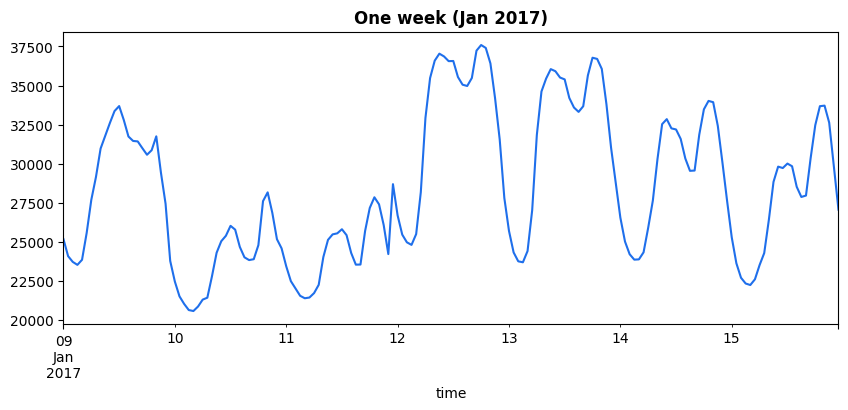

In [ ]:
wk = load[(load.index >= pd.Timestamp("2017-01-09", tz="UTC")) & (load.index <= pd.Timestamp("2017-01-15 23:00", tz="UTC"))]
wk.plot(color=BLUE, title="One week (Jan 2017)"); plt.show()

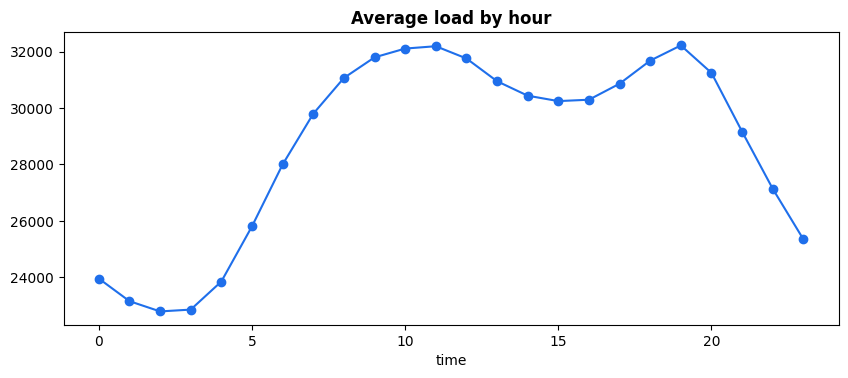

In [ ]:
load.groupby(load.index.hour).mean().plot(marker="o", color=BLUE, title="Average load by hour"); plt.show()

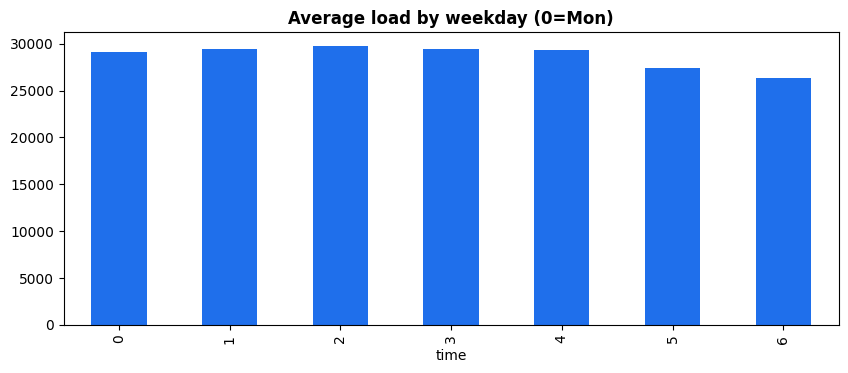

In [ ]:
load.groupby(load.index.dayofweek).mean().plot.bar(color=BLUE, title="Average load by weekday (0=Mon)"); plt.show()

>  **Answer:** There is a clear daily rhythm. Demand is lowest during the early morning, rises rapidly after around 5 a.m., reaches a daytime peak, decreases slightly in the afternoon, and rises again in the evening. There is also a weekend effect because Saturday and especially Sunday have lower average demand than weekdays.


## 4 · Autocorrelation
Run the cell. **Q:** is the past predictive? which lag matters most besides t-1?

In [ ]:
for lag in [1, 24, 48, 168]:
    print(f"lag {lag:4d} h  ->  autocorr = {load.autocorr(lag):.2f}")

lag    1 h  ->  autocorr = 0.95
lag   24 h  ->  autocorr = 0.70
lag   48 h  ->  autocorr = 0.55
lag  168 h  ->  autocorr = 0.66


>  **Answer:** Yes, past electricity demand is strongly predictive of current demand. Lag 1 has the highest autocorrelation at 0.95. Excluding lag 1, lag 24 is the strongest at 0.70, meaning demand at the same hour yesterday is an important predictor. Lag 168 is also strong at 0.66 because of weekly repetition.

## 5 · External driver — temperature
Run the cell. **Q:** is demand related to temperature? linear or not?

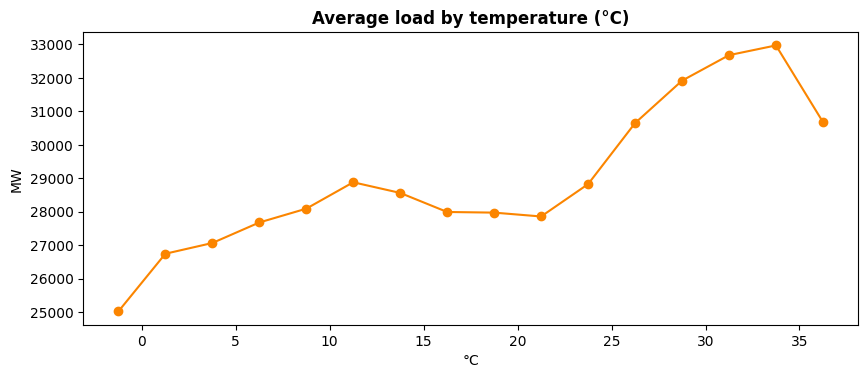

linear correlation: 0.21


In [ ]:
wmean = weather.drop_duplicates(subset=["dt_iso", "city_name"]).groupby("dt_iso")["temp"].mean()
df = energy.set_index("time").assign(temp_C=wmean - 273.15)
m = df.dropna(subset=["temp_C", "total load actual"])
curve = m.groupby(pd.cut(m["temp_C"], np.arange(-5, 46, 2.5)), observed=True)["total load actual"].mean()
plt.plot([i.mid for i in curve.index], curve.values, marker="o", color=ORANGE)
plt.title("Average load by temperature (°C)"); plt.xlabel("°C"); plt.ylabel("MW"); plt.show()
print("linear correlation:", round(m["temp_C"].corr(m["total load actual"]), 2))

>  **Answer:** Electricity demand is related to temperature, but the relationship is not linear. Demand generally increases at very high temperatures, especially above approximately 25°C, possibly because of increased air-conditioning use. The linear correlation is only 0.21, so a simple straight-line relationship does not fully represent the pattern.

## 6 · Before cleaning — a quick look
Run the cells. **Q:** any missing values (which columns)? what dominates the generation mix?

In [ ]:
miss = energy.isna().mean() * 100
print(miss[miss > 0].sort_values(ascending=False).round(1).to_string())

generation hydro pumped storage aggregated     100.0
forecast wind offshore eday ahead              100.0
total load actual                                0.1
generation hydro pumped storage consumption      0.1
generation biomass                               0.1
generation fossil oil                            0.1
generation marine                                0.1
generation hydro run-of-river and poundage       0.1
generation waste                                 0.1
generation fossil oil shale                      0.1
generation fossil coal-derived gas               0.1
generation fossil brown coal/lignite             0.1
generation fossil hard coal                      0.1
generation fossil gas                            0.1
generation fossil peat                           0.1
generation solar                                 0.1
generation hydro water reservoir                 0.1
generation geothermal                            0.1
generation other                              

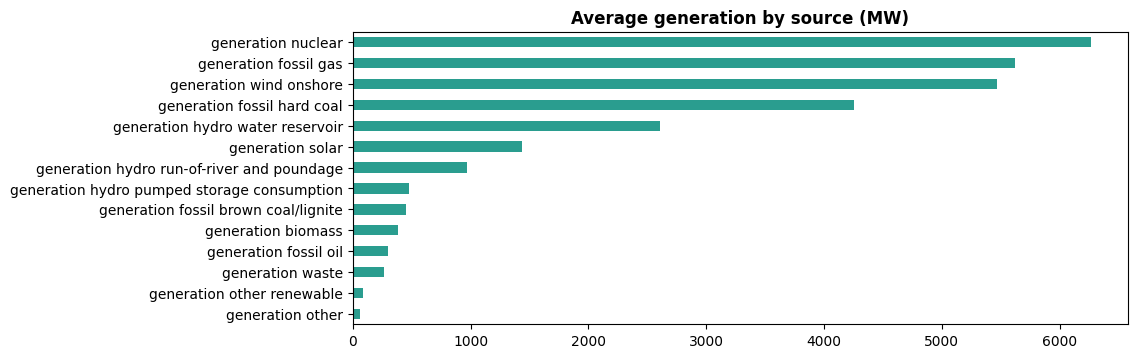

In [ ]:
gen = [c for c in energy.columns if c.startswith("generation")]
mix = energy[gen].mean(); mix = mix[mix > 0].sort_values()
mix.plot.barh(color=GREEN, title="Average generation by source (MW)"); plt.show()

>  **Answer:** Two columns are completely missing: generation hydro pumped storage aggregated and forecast wind offshore eday ahead. Several other columns, including total load actual, have a small percentage of missing values of approximately 0.1%. The generation mix is mainly dominated by nuclear energy, followed by fossil gas, onshore wind and fossil hard coal.

## Reading notes → Part B
From your answers, fill the table:

| Observation | Next decision |
|---|---|
|  |  |
|  |  |
|  |  |
|  |  |